In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str # 사용자 질문
    answer: str # 세율
    tax_base_equation: str # 과세표준 계산 수식
    tax_deduction: str # 공제액
    market_ratio: str # 공정시장가액비율
    tax_base: str # 과세표준 계산

graph_builder = StateGraph(AgentState)

In [3]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embedding_function = OpenAIEmbeddings(model='text-embedding-3-large')
vector_store = Chroma(
    embedding_function = embedding_function,
    collection_name = 'real_estate_tax',
    persist_directory='./real_estate_tax_collection',
)
retriever = vector_store.as_retriever(search_kwargs={'k': 3})

In [4]:
query = '5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때 세금을 얼마나 내나요?'

In [5]:
from langchain_openai import ChatOpenAI
from langsmith import Client
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_core.prompts import ChatPromptTemplate
 
client = Client()

rag_prompt = client.pull_prompt('rlm/rag-prompt', dangerously_pull_public_prompt=True)
llm = ChatOpenAI(model='gpt-4o')
small_llm = ChatOpenAI(model='gpt-4o-mini')

In [6]:
tax_base_retrieval_chain = (
    {'context': retriever, 'question': RunnablePassthrough()}
    | rag_prompt
    | llm
    | StrOutputParser()
)

tax_base_equation_prompt = ChatPromptTemplate.from_messages([
    ('system', '아래 설명에서 과세표준 계산 방법을 수식으로만 추출하세요. 부연설명 없이 수식만 반환하세요.'),
    ('human', '{tax_base_equation_information}')
])

tax_base_equation_chain = (
    {'tax_base_equation_information': RunnablePassthrough()}
    | tax_base_equation_prompt
    | llm
    | StrOutputParser()
)

tax_base_chain = tax_base_retrieval_chain | tax_base_equation_chain

def get_tax_base_equation(state: AgentState):
    tax_base_equation_question = '주택에 대한 종합부동산세 계산시 과세표준을 계산하는 방법을 수식으로 표현해서 알려주세요'
    tax_base_equation = tax_base_chain.invoke(tax_base_equation_question)
    return {'tax_base_equation': tax_base_equation}

In [7]:

# {'tax_base_equation': '과세표준 = (주택 공시가격 합계 - 공제금액) × 공정시장가액비율'}

In [8]:
tax_deduction_chain = (
    {'context': retriever, 'question': RunnablePassthrough()}
    | rag_prompt
    | llm
    | StrOutputParser()
)

def get_tax_deduction(state: AgentState):
    tax_deduction_question = '주택에 대한 종합부동산세 계산시 공제금액을 알려주세요'
    tax_deduction = tax_deduction_chain.invoke(tax_deduction_question)
    return {'tax_deduction': tax_deduction}

In [9]:
# {'tax_deduction': '주택에 대한 종합부동산세 계산 시 공제금액은 상황에 따라 다릅니다. 1세대 1주택자의 경우 12억 원이 공제되며, 그 외의 경우 9억 원이 공제됩니다. 법인 또는 법인으로 보는 단체의 경우에는 6억 원이 공제됩니다.'}

In [10]:
from langchain_tavily import TavilySearch
from datetime import date

tavily_search_tool = TavilySearch(
    max_results=5,
    search_depth="advanced",
    include_answer=True,
    include_raw_content=False,
    include_images=False,
)

tax_market_ratio_prompt = ChatPromptTemplate.from_messages([
    ('system', f'아래 정보를 기반으로 공정시장 가액비율을 계산해주세요\n\nContext:\n{{context}}'),
    ('human', '{query}')
])

def get_market_ratio(state: AgentState):
    query = f'오늘 날짜:({date.today()})에 해당하는 주택 공시가격 공정시장가액비율은 몇%인가요?'
    context = tavily_search_tool.invoke(query)
    print(f'context == {context}')
    tax_market_ratio_chain = (
        tax_market_ratio_prompt
        | llm
        | StrOutputParser()
    )
    market_ratio = tax_market_ratio_chain.invoke({
        'context': context,
        'query': query,
    })
    return {'market_ratio': market_ratio}

In [11]:
# {'market_ratio': '2026년 현재 주택 공시가격에 대한 공정시장가액비율은 60%입니다.'}

In [12]:
from langchain_core.prompts import ChatPromptTemplate

tax_base_calculation_prompt = ChatPromptTemplate.from_messages(
    [
        ('system',"""
주어진 내용을 기반으로 과세표준을 계산해주세요

과세표준 계산 공식: {tax_base_equation}
공제금액: {tax_deduction}
공정시장가액비율: {market_ratio}"""),
        ('human', '사용자 주택 공시가격 정보: {query}')
    ]
)

def calculate_tax_base(state: AgentState):
    tax_base_equation = state['tax_base_equation']
    tax_deduction = state['tax_deduction']
    market_ratio = state['market_ratio']
    query = state['query']
    tax_base_calculation_chain =(
        tax_base_calculation_prompt
        | llm
        | StrOutputParser()
    )
    tax_base = tax_base_calculation_chain.invoke({
        'tax_base_equation': tax_base_equation,
        'tax_deduction': tax_deduction,
        'market_ratio': market_ratio,
        'query': query,
    })
    print(f'tax_base == {tax_base}')
    return {'tax_base': tax_base}

In [13]:
initial_state = {
    'tax_base_equation': '과세표준 = (주택 공시가격 합계 - 공제금액) × 공정시장가액비율',
    'tax_deduction': '주택에 대한 종합부동산세 계산 시 공제금액은 상황에 따라 다릅니다. 1세대 1주택자의 경우 12억 원이 공제되며, 그 외의 경우 9억 원이 공제됩니다. 법인 또는 법인으로 보는 단체의 경우에는 6억 원이 공제됩니다.',
    'market_ratio': '2026년 현재 주택 공시가격에 대한 공정시장가액비율은 60%입니다.',
    'query': query
}


In [14]:
tax_rate_calculation_prompt = ChatPromptTemplate.from_messages([
    ('system', '''당신은 종합부동산세 계산 전문가입니다. 아래 문서를 참고해서 사용자의 질문에 대한 종합부동산세를 계산해주세요
     
종합부동산세 세율:{context}'''),
    ('human', '''과세표준과 사요자가 소지한 주택의 수가 아래와 같을 때 종합부동산세를 계산해주세요
     
과세표준: {tax_base}
주택 수:{query}''')
])


def calculate_tax_rate(state: AgentState):
    query = state['query']
    tax_base = state['tax_base']
    context = retriever.invoke(query)
    tax_rate_chain = (
        tax_rate_calculation_prompt
        | llm
        | StrOutputParser()
    )
    tax_rate = tax_rate_chain.invoke({
        'context': context,
        'tax_base': tax_base,
        'query': query,
    })
    print(f'tax_rate == {tax_rate}')
    return {'answer': tax_rate}

In [15]:
calculate_tax_base(initial_state)

tax_base == 사용자가 3채의 주택을 소유하고 있으며, 이는 1세대 1주택자에 해당하지 않으므로 9억 원의 공제금액이 적용됩니다. 주택 공시가격 합계는 다음과 같습니다:

- 5억 원짜리 집 1채
- 10억 원짜리 집 1채
- 20억 원짜리 집 1채

공시가격 합계: 5억 원 + 10억 원 + 20억 원 = 35억 원

과세표준은 다음과 같이 계산됩니다:

과세표준 = (주택 공시가격 합계 - 공제금액) × 공정시장가액비율
과세표준 = (35억 원 - 9억 원) × 60%
과세표준 = 26억 원 × 0.60
과세표준 = 15.6억 원

따라서 사용자의 과세표준은 15.6억 원입니다. 이는 사용자가 종합부동산세를 계산하기 위한 과세표준이며, 이 금액에 해당하는 세율을 적용하여 세금을 산출하게 됩니다. 세율은 별도로 확인해야 합니다.


{'tax_base': '사용자가 3채의 주택을 소유하고 있으며, 이는 1세대 1주택자에 해당하지 않으므로 9억 원의 공제금액이 적용됩니다. 주택 공시가격 합계는 다음과 같습니다:\n\n- 5억 원짜리 집 1채\n- 10억 원짜리 집 1채\n- 20억 원짜리 집 1채\n\n공시가격 합계: 5억 원 + 10억 원 + 20억 원 = 35억 원\n\n과세표준은 다음과 같이 계산됩니다:\n\n과세표준 = (주택 공시가격 합계 - 공제금액) × 공정시장가액비율\n과세표준 = (35억 원 - 9억 원) × 60%\n과세표준 = 26억 원 × 0.60\n과세표준 = 15.6억 원\n\n따라서 사용자의 과세표준은 15.6억 원입니다. 이는 사용자가 종합부동산세를 계산하기 위한 과세표준이며, 이 금액에 해당하는 세율을 적용하여 세금을 산출하게 됩니다. 세율은 별도로 확인해야 합니다.'}

In [16]:
tax_base_state = {'tax_base': '사용자가 소유한 주택의 공시가격 합계는 5억 원 + 10억 원 + 20억 원 = 35억 원입니다.\n\n이 경우 "1세대 1주택자"가 아닌 경우이므로 공제금액은 9억 원이 됩니다.\n\n따라서 과세표준을 계산하면 다음과 같습니다.\n\n과세표준 = (35억 원 - 9억 원) × 60%\n              = 26억 원 × 60%\n              = 15.6억 원\n\n이 과세표준에 따라 해당하는 종합부동산세를 계산하면 됩니다. 다만, 세율에 대한 정보는 주어지지 않았으므로 추가로 관련 세율표를 참조하여 실제 세금을 계산해야 합니다.', 'query': query}

In [17]:
calculate_tax_rate(tax_base_state)

tax_rate == 사용자가 3채의 주택을 소유하고 있으며, 과세표준이 15.6억 원인 경우에 대한 종합부동산세를 계산합니다. 3주택 이상 소유자의 경우 세율표를 참조하여 세금을 계산합니다.

주어진 과세표준 15.6억 원에 대한 세율표는 다음과 같습니다:
- 12억 원 초과 25억 원 이하: 960만 원 + (12억 원을 초과하는 금액의 1천분의 20)

여기서 과세표준 15.6억 원은 12억 원을 초과하므로, 초과하는 금액은:
15.6억 원 - 12억 원 = 3.6억 원

따라서, 세금은 다음과 같이 계산됩니다:
- 기본 세액: 960만 원
- 추가 세액: 3.6억 원 × 1천분의 20 = 720만 원 (3.6억 원 × 0.002)

총 종합부동산세 = 960만 원 + 720만 원 = 1,680만 원

따라서, 사용자는 1,680만 원의 종합부동산세를 납부해야 합니다.


{'answer': '사용자가 3채의 주택을 소유하고 있으며, 과세표준이 15.6억 원인 경우에 대한 종합부동산세를 계산합니다. 3주택 이상 소유자의 경우 세율표를 참조하여 세금을 계산합니다.\n\n주어진 과세표준 15.6억 원에 대한 세율표는 다음과 같습니다:\n- 12억 원 초과 25억 원 이하: 960만 원 + (12억 원을 초과하는 금액의 1천분의 20)\n\n여기서 과세표준 15.6억 원은 12억 원을 초과하므로, 초과하는 금액은:\n15.6억 원 - 12억 원 = 3.6억 원\n\n따라서, 세금은 다음과 같이 계산됩니다:\n- 기본 세액: 960만 원\n- 추가 세액: 3.6억 원 × 1천분의 20 = 720만 원 (3.6억 원 × 0.002)\n\n총 종합부동산세 = 960만 원 + 720만 원 = 1,680만 원\n\n따라서, 사용자는 1,680만 원의 종합부동산세를 납부해야 합니다.'}

In [18]:
graph_builder.add_node('get_tax_base_equation', get_tax_base_equation)
graph_builder.add_node('get_tax_deduction', get_tax_deduction)
graph_builder.add_node('get_market_ratio', get_market_ratio)
graph_builder.add_node('calculate_tax_base', calculate_tax_base)
graph_builder.add_node('calculate_tax_rate', calculate_tax_rate)

In [19]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'get_tax_base_equation')
graph_builder.add_edge(START, 'get_tax_deduction')
graph_builder.add_edge(START, 'get_market_ratio')
graph_builder.add_edge('get_tax_base_equation', 'calculate_tax_base')
graph_builder.add_edge('get_tax_deduction', 'calculate_tax_base')
graph_builder.add_edge('get_market_ratio', 'calculate_tax_base')
graph_builder.add_edge('calculate_tax_base', 'calculate_tax_rate')
graph_builder.add_edge('calculate_tax_rate', END)

In [20]:
graph = graph_builder.compile()

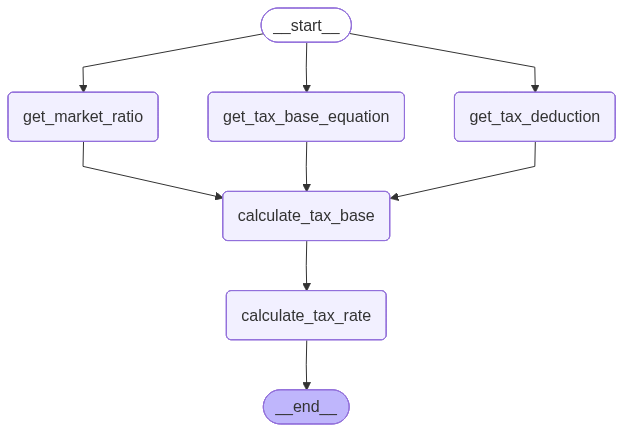

In [21]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
initial_state = {'query': query}
graph.invoke(initial_state)

context == {'query': '오늘 날짜:(2026-05-15)에 해당하는 주택 공시가격 공정시장가액비율은 몇%인가요?', 'follow_up_questions': None, 'answer': 'For 2026, the public fair market value rate is 60% for housing property taxes. This rate determines the taxable value used for calculating property taxes. The rate is subject to annual adjustments by the government.', 'images': [], 'results': [{'url': 'https://v.daum.net/v/20260317160802885', 'title': '[2026 공시가격] 李정부, 공시가 손질 착수...내년부터 상승 가능성', 'content': '부동산 업계에서는 공시가격이 재산세와 종합부동산세 등 보유세 산정의 기준이 되는 핵심 지표인 만큼, 공시가격 현실화율이 조정될 경우 보유세 변화는 불가피할 것으로 분석한다.\n\n현재 재산세는 1가구 1주택자를 기준으로 공정시장가액비율이 공시가격 3억원 초과 6억원 이하 구간은 44%, 6억원 초과 구간은 45%가 적용된다. 종합부동산세는 1가구 1주택 기준 기본공제 12억원과 공정시장가액비율 60%가 적용된다.\n\n이에 따라 공시가격이 상승하면 재산세와 종합부동산세 과세표준이 높아지면서 보유세 부담도 함께 증가하게 된다. 특히 고가 주택의 경우, 종합부동산세 과세 대상이 되는 경우가 많아 공시가격 변동에 따른 세금 영향이 상대적으로 크게 나타날 수 있다.\n\n서진형 광운대 부동산법무학과 교수는 "공시가격 현실화율이 90% 수준으로 상향될 경우 세 부담을 느낀 보유자들이 매물을 시장에 내놓으면서 일정 부분 공급 확대 효과를 기대할 수 있다"면서도 "다만 조세 부담이 급격히 늘어나면 임대료로 전가되는 등 부작용이 나타날 수 있는

{'query': '5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때 세금을 얼마나 내나요?',
 'answer': '주어진 정보를 바탕으로 과세표준 15억 6천만 원에 대한 종합부동산세를 계산해 보겠습니다.\n\n사용자는 3주택을 소지하고 있기 때문에 "납세의무자가 3주택 이상을 소유한 경우"에 대한 세율을 적용해야 합니다.\n\n과세표준이 15억 6천만 원인 경우, 세율은 아래와 같이 적용됩니다.\n\n1. 과세표준 12억 원 초과 25억 원 이하: 960만 원 + (12억 원을 초과하는 금액의 1천분의 20)\n\n계산:\n- 12억 원을 초과하는 금액: 15억 6천만 원 - 12억 원 = 3억 6천만 원\n- 초과분에 대한 세금: (3억 6천만 원 × 0.0020) = 720만 원\n- 총 세금: 960만 원 + 720만 원 = 1,680만 원\n\n따라서 3채의 주택을 소유한 상태에서의 종합부동산세는 총 1,680만 원이 될 것입니다.',
 'tax_base_equation': '과세표준 = (공시가격 합계 - 공제 금액) × 공정시장가액비율',
 'tax_deduction': '주택에 대한 종합부동산세 계산 시, 1세대 1주택자는 12억원의 공제를 받을 수 있습니다. 법인 또는 법인으로 보는 단체는 6억원의 공제를 받으며, 그 외의 경우에는 9억원의 공제가 적용됩니다.',
 'market_ratio': '2026년 주택 공시가격의 공정시장가액비율은 60%입니다.',
 'tax_base': '주어진 주택 공시가격 정보에 따라 과세표준을 계산하겠습니다.\n\n1. 주택 공시가격 합계:\n   - 5억 + 10억 + 20억 = 35억 원\n\n2. 공제 금액:\n   - 여러 주택을 소유한 경우, 일반적으로 9억 원의 공제가 적용됩니다.\n\n3. 과세표준 계산:\n   - 과세표준 = (공시가격 합계 - 공제 금액) × 공정시장가액비율\n   - 과세표준 = (35억 - 9억) × 60%\n   - 과세표준 = 26억 × 0